# Финальный проект
# Notebook 2. Experiment Design

Построение пользовательской воронки, расчет продуктовых метрик, дисперсий и MDE.

## 1. Импорт библиотек

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns',None)
pd.set_option('display.float_format','{:.4f}'.format)
plt.style.use('ggplot')

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Загрузка данных

In [6]:
df=pd.read_csv('//content/drive/MyDrive/Colab Notebooks/Финальный проект/stream_events.csv')
df['dt']=pd.to_datetime(df['dt'])
df['date']=df['dt'].dt.date
df.head()

,dt,client_id,event_type,content_id,watch_time_min,date
0,2025-04-19 13:02:27,1025,click_banner,126,NaN,2025-04-19
1,2025-04-07 11:21:16,1754,view_banner,380,NaN,2025-04-07
2,2025-04-26 20:57:25,1089,click_banner,17,NaN,2025-04-26
3,2025-04-01 20:44:19,1223,view_banner,309,NaN,2025-04-01
4,2025-04-01 18:28:08,1203,click_banner,360,NaN,2025-04-01


## 3. Построение пользовательской воронки

In [7]:
events=df.copy()

counts=(events
.pivot_table(index=['date','client_id'],
             columns='event_type',
             values='content_id',
             aggfunc='count',
             fill_value=0)
.reset_index())

for col in ['view_banner','click_banner','start_watch','finish_watch']:
    if col not in counts.columns:
        counts[col]=0

watch=(events[events.event_type=='finish_watch']
.groupby(['date','client_id'])['watch_time_min']
.sum()
.reset_index(name='watch_time'))

funnel=counts.merge(watch,on=['date','client_id'],how='left')
funnel['watch_time']=funnel['watch_time'].fillna(0)
funnel['adds_to_fav']=0

funnel=funnel.rename(columns={
'view_banner':'views',
'click_banner':'clicks'
})

funnel.head()

,date,client_id,clicks,finish_watch,start_watch,views,watch_time,adds_to_fav
0,2025-04-01,1203,1,0,0,0,0.0000,0
1,2025-04-01,1223,0,0,0,1,0.0000,0
2,2025-04-01,1323,0,0,0,1,0.0000,0
3,2025-04-01,1636,0,1,0,0,19.0000,0
4,2025-04-02,1069,1,0,0,0,0.0000,0


## 4. Расчет пользовательских метрик

In [8]:
metrics=funnel.copy()

metrics['CTR']=np.where(metrics['views']>0,
                        metrics['clicks']/metrics['views'],
                        0)

metrics['Avg_Watch_Time']=np.where(metrics['clicks']>0,
                                   metrics['watch_time']/metrics['clicks'],
                                   0)

metrics['CR_fav']=0.0

metrics['ARPU']=metrics['watch_time']

metrics.head()

,date,client_id,clicks,finish_watch,start_watch,views,watch_time,adds_to_fav,CTR,Avg_Watch_Time,CR_fav,ARPU
0,2025-04-01,1203,1,0,0,0,0.0000,0,0.0000,0.0000,0.0000,0.0000
1,2025-04-01,1223,0,0,0,1,0.0000,0,0.0000,0.0000,0.0000,0.0000
2,2025-04-01,1323,0,0,0,1,0.0000,0,0.0000,0.0000,0.0000,0.0000
3,2025-04-01,1636,0,1,0,0,19.0000,0,0.0000,0.0000,0.0000,19.0000
4,2025-04-02,1069,1,0,0,0,0.0000,0,0.0000,0.0000,0.0000,0.0000


## 5. Средние значения

In [9]:
summary=metrics[['CTR','Avg_Watch_Time','CR_fav','ARPU']].agg(['mean','median','std'])
summary

,CTR,Avg_Watch_Time,CR_fav,ARPU
mean,0.0000,0.0000,0.0000,5.3400
median,0.0000,0.0000,0.0000,0.0000
std,0.0000,0.0000,0.0000,20.2541


## 6. Визуализация

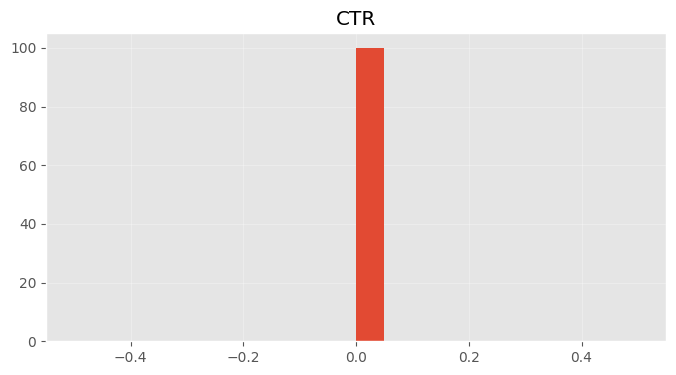

In [10]:
plt.figure(figsize=(8,4))
plt.hist(metrics['CTR'],bins=20)
plt.title('CTR')
plt.grid(alpha=.3)
plt.show()

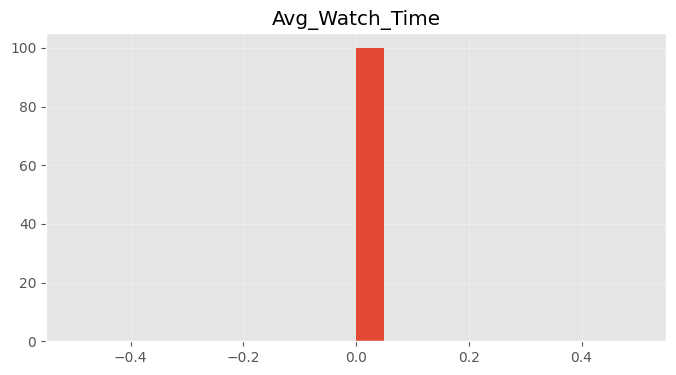

In [11]:
plt.figure(figsize=(8,4))
plt.hist(metrics['Avg_Watch_Time'],bins=20)
plt.title('Avg_Watch_Time')
plt.grid(alpha=.3)
plt.show()

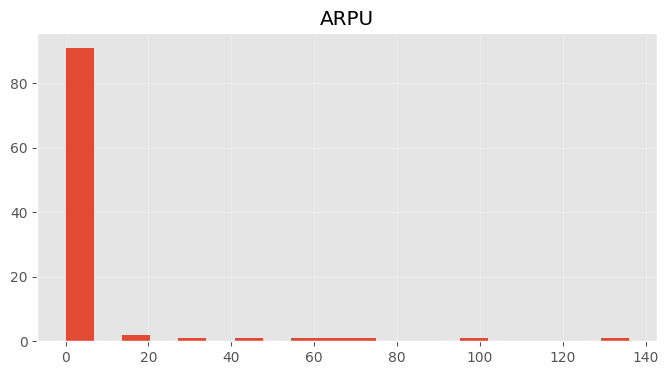

In [12]:
plt.figure(figsize=(8,4))
plt.hist(metrics['ARPU'],bins=20)
plt.title('ARPU')
plt.grid(alpha=.3)
plt.show()

## 7. Расчет дисперсий

In [13]:
def var_ratio(x,y):
    mean_x=np.mean(x)
    mean_y=np.mean(y)
    var_x=np.var(x,ddof=1)
    var_y=np.var(y,ddof=1)
    cov_xy=np.cov(x,y,ddof=1)[0][1]
    return var_x/mean_y**2 + var_y*mean_x**2/mean_y**4 - 2*mean_x*cov_xy/mean_y**3

ctr_var=var_ratio(metrics['clicks'],metrics['views'])

valid=metrics['clicks']>0
watch_var=var_ratio(metrics.loc[valid,'watch_time'],
                    metrics.loc[valid,'clicks']) if valid.any() else np.nan

arpu_var=metrics['ARPU'].var(ddof=1)

variance_table=pd.DataFrame({
'Metric':['CTR','Avg Watch Time','ARPU'],
'Variance':[ctr_var,watch_var,arpu_var]
})
variance_table

,Metric,Variance
0,CTR,1.8496
1,Avg Watch Time,0.0000
2,ARPU,410.2267


## 8. Расчет MDE

In [14]:
def get_MDE(mu,std,sample_size,n_groups=2,target_share=0.5,r=1,alpha=0.05,beta=0.2):
    t_alpha=stats.norm.ppf(1-alpha/2)
    t_beta=stats.norm.ppf(1-beta)
    corr=r+2+1/r
    mde=np.sqrt(corr)*(t_alpha+t_beta)*std/np.sqrt(sample_size*(1-target_share*(n_groups-1)))
    return mde,mde*100/mu if mu!=0 else np.nan

total_users=metrics['client_id'].nunique()
sample_size=max(2,int(total_users*0.15))
mu=metrics['Avg_Watch_Time'].mean()
std=metrics['Avg_Watch_Time'].std(ddof=1)

mde_abs,mde_pct=get_MDE(mu,std,sample_size)

mde_results=pd.DataFrame({
'Metric':['Avg Watch Time'],
'Users':[total_users],
'Sample Size':[sample_size],
'MDE':[mde_abs],
'MDE %':[mde_pct]
})
mde_results

,Metric,Users,Sample Size,MDE,MDE %
0,Avg Watch Time,95,14,0.0000,NaN


## 9. Сохранение результатов

In [17]:
funnel.to_csv('/content/drive/MyDrive/Colab Notebooks/Финальный проект/funnel.csv',index=False)
summary.to_csv('/content/drive/MyDrive/Colab Notebooks/Финальный проект/metrics_summary.csv')
mde_results.to_csv('/content/drive/MyDrive/Colab Notebooks/Финальный проект/mde_results.csv',index=False)

print('Файлы успешно сохранены:')
print('- funnel.csv')
print('- metrics_summary.csv')
print('- mde_results.csv')

Файлы успешно сохранены:
- funnel.csv
- metrics_summary.csv
- mde_results.csv
